In [2]:
# STEP 1 — Install & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Blues_d")

print("✅ Libraries loaded successfully")

✅ Libraries loaded successfully


In [4]:
# STEP 2 — Load Data
from google.colab import files
uploaded = files.upload()



Saving RFM.xlsx to RFM.xlsx


In [5]:
# Load the exported RFM table
df = pd.read_excel('RFM.xlsx')

print(f"Total rows loaded : {len(df):,}")
print(f"Columns           : {list(df.columns)}")
print(f"\nSegment distribution:")
print(df['segment'].value_counts())

Total rows loaded : 96,477
Columns           : ['customer_id', 'recency', 'frequency', 'monetary', 'recent_rnk', 'frequency_rnk', 'monetary_rnk', 'score', 'rfm_score', 'segment', 'Revenue_rnk', 'monetary_rank', 'monetary_rank (bins)']

Segment distribution:
segment
Loyal Customer         32895
At Risk                32386
Top Customer           16342
Immediate Attention    14854
Name: count, dtype: int64


In [6]:
# STEP 3 — Isolate At Risk Cohort
# WHY: We established in our segmentation analysis that Immediate Attention customers (avg recency 425 days)
# are beyond coupon-based recovery.
# At Risk customers (avg recency 305 days) are the actionable cohort.

at_risk = df[df['segment'] == 'At Risk'].copy()
#print(at_risk)
at_risk = at_risk.reset_index(drop=True)
print(at_risk)

print(f"\nAt Risk cohort size : {len(at_risk):,}")
print(f"Avg recency (days)  : {at_risk['recency'].mean():.0f}")
print(f"Avg monetary ($)    : {at_risk['monetary'].mean():.2f}")
print(f"Total GMV at risk   : ${at_risk['monetary'].sum():,.2f}")

                            customer_id  recency  frequency  monetary  \
0      8a7211caed65d95327c162a2b3504e95      279          1    116.24   
1      68db318fa01188d9aa08594fb543704a      279          1    116.24   
2      1579d7904c35a5fd9a2d5ddd03e57934      279          1    116.24   
3      35148f0d009a1f17f54bdadaf07a4bf0      279          1    115.94   
4      4942083df2e79bb7ecb6728281a16b35      279          1    115.44   
...                                 ...      ...        ...       ...   
32381  29c3dfdabea255ab06e66922a280d4ac      374          1     77.57   
32382  528afb11d81bed37164a6a3387510a4b      377          1     77.57   
32383  860b1d9e8b261a7ec7cbe827d7cf3aa2      376          1     77.57   
32384  d694672edc54700d8ca5ed650115ee59      377          1     77.57   
32385  ba1fefc7aa34744954bead4700a08f4d      377          1     77.57   

       recent_rnk  frequency_rnk  monetary_rnk  score  rfm_score  segment  \
0               4              0             5

In [7]:
# STEP 4 — Assign Treatment & Control Groups
# Split: 80% Treatment (receive discount coupon)
#        20% Control   (no discount, business as usual)

np.random.seed(42)  # for reproducibility

at_risk['group'] = np.random.choice(
    ['Treatment', 'Control'],
    size=len(at_risk),
    p=[0.8, 0.2]          # 80% treatment, 20% control
)

print("\nGroup assignment:")
print(at_risk['group'].value_counts())
print("\nGroup split %:")
print(at_risk['group'].value_counts(normalize=True).round(3) * 100)


Group assignment:
group
Treatment    25926
Control       6460
Name: count, dtype: int64

Group split %:
group
Treatment    80.1
Control      19.9
Name: proportion, dtype: float64


In [8]:
# STEP 5 — SANITY CHECK: Are the two groups comparable?
balance_check = at_risk.groupby('group').agg(
    customer_count  = ('customer_id', 'count'),
    avg_recency     = ('recency', 'mean'),
    avg_frequency   = ('frequency', 'mean'),
    avg_monetary    = ('monetary', 'mean')
).round(2)

print("\n📊 Balance Check — Pre-experiment group comparison:")
print(balance_check)


📊 Balance Check — Pre-experiment group comparison:
           customer_count  avg_recency  avg_frequency  avg_monetary
group                                                              
Control              6460       305.27            1.0        111.12
Treatment           25926       305.16            1.0        110.99


In [9]:
# STEP 6 — SIMULATE CAMPAIGN OUTCOMES
# we simulate 60-day repurchase outcomes using
# realistic conversion probabilities based on industry
# benchmarks for e-commerce retention campaigns.
#
# Treatment (with 10% discount): 25% repurchase rate
# Control   (no discount)      : 12% repurchase rate
# These are conservative, realistic assumptions.

# Conversion probabilities
treatment_conversion_rate = 0.25   # 25% — with discount
control_conversion_rate   = 0.12   # 12% — without discount

# Simulate conversion outcome (1 = repurchased, 0 = did not)
at_risk['converted'] = at_risk['group'].apply(
    lambda g: np.random.binomial(
        1,
        treatment_conversion_rate if g == 'Treatment' else control_conversion_rate
    )
)




# Simulate post-campaign order value for converted customers
# Treatment: slight reduction due to discount applied
# Control  : full price, natural repurchase

at_risk['post_campaign_value'] = at_risk.apply(
    lambda row: round(np.random.normal(
        loc  = row['monetary'] * 0.9 if row['group'] == 'Treatment' else row['monetary'],
        scale= row['monetary'] * 0.1
    ), 2) if row['converted'] == 1 else 0,
    axis=1
)

# # Clip negative values (edge case from normal distribution)
# at_risk['post_campaign_value'] = at_risk['post_campaign_value'].clip(lower=0)

# print("\n✅ Campaign outcomes simulated")
# print(at_risk.groupby('group')['converted'].mean().round(3))


In [10]:
# STEP 7 — MEASURE PRIMARY METRIC
#          Conversion Rate: Treatment vs Control
# ────────────────────────────────────────────────────────────

results = at_risk.groupby('group').agg(
    total_customers     = ('customer_id', 'count'),
    converted           = ('converted', 'sum'),
    conversion_rate     = ('converted', 'mean'),
    avg_order_value     = ('post_campaign_value',
                           lambda x: x[x > 0].mean()),
    total_revenue       = ('post_campaign_value', 'sum')
).round(3)

results['conversion_rate_pct'] = (results['conversion_rate'] * 100).round(1)
print(results)

#print("\n📊 Campaign Results — Primary Metric:")
#print(results[['total_customers', 'converted','conversion_rate_pct', 'avg_order_value','total_revenue']])




           total_customers  converted  conversion_rate  avg_order_value  \
group                                                                     
Control               6460        772            0.120          119.187   
Treatment            25926       6462            0.249           98.908   

           total_revenue  conversion_rate_pct  
group                                          
Control         92012.74                 12.0  
Treatment      639140.49                 24.9  


In [11]:
# Lift calculation
treatment_rate = results.loc['Treatment', 'conversion_rate']
control_rate   = results.loc['Control',   'conversion_rate']
absolute_lift  = treatment_rate - control_rate
relative_lift  = (absolute_lift / control_rate) * 100

print(f"\nAbsolute lift : +{absolute_lift:.1%}")
print(f"Relative lift : +{relative_lift:.1f}%")


Absolute lift : +12.9%
Relative lift : +107.5%


In [12]:
# STEP 8 — STATISTICAL SIGNIFICANCE TEST
#
# Chi-square test for proportions
#
# H0 (Null hypothesis)     : Conversion rates are equal
#                            across Treatment and Control
# H1 (Alternate hypothesis): Treatment has a higher
#                            conversion rate than Control
#
# Decision rule: If p-value < 0.05 → reject H0
#                Result is statistically significant
# ────────────────────────────────────────────────────────────

# Build contingency table
treatment_converted     = results.loc['Treatment', 'converted']
treatment_not_converted = results.loc['Treatment', 'total_customers'] - treatment_converted
control_converted       = results.loc['Control',   'converted']
control_not_converted   = results.loc['Control',   'total_customers'] - control_converted

contingency_table = np.array([
    [treatment_converted,     treatment_not_converted],
    [control_converted,       control_not_converted]
])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\n📊 Statistical Significance Test (Chi-Square):")
print(f"Chi-square statistic : {chi2:.4f}")
print(f"p-value              : {p_value:.6f}")
print(f"Degrees of freedom   : {dof}")


if p_value < 0.05:
    print("\n✅ Result is STATISTICALLY SIGNIFICANT (p < 0.05)")
    print("   We reject H0 — the discount campaign has a")
    print("   genuine effect on repurchase rate.")
else:
    print("\n❌ Result is NOT statistically significant (p >= 0.05)")
    print("   We cannot conclude the discount drove repurchases.")


📊 Statistical Significance Test (Chi-Square):
Chi-square statistic : 501.0674
p-value              : 0.000000
Degrees of freedom   : 1

✅ Result is STATISTICALLY SIGNIFICANT (p < 0.05)
   We reject H0 — the discount campaign has a
   genuine effect on repurchase rate.


In [17]:
# Split at-risk Treatment customers by GMV tier
treatment_df = at_risk[at_risk['group'] == 'Treatment'].copy()
treatment_df['gmv_tier'] = pd.cut(
    treatment_df['monetary'],
    bins=[0, 100, 200, 300, float('inf')],
    labels=['<$100', '$100-200', '$200-300', '>$300']
)
gmv_conversion = treatment_df.groupby('gmv_tier').agg(
    customers     = ('customer_id', 'count'),
    converted     = ('converted', 'sum'),
    conv_rate     = ('converted', 'mean')
).round(3)
gmv_conversion['conv_rate_pct'] = (gmv_conversion['conv_rate'] * 100).round(1)
print(gmv_conversion)

          customers  converted  conv_rate  conv_rate_pct
gmv_tier                                                
<$100         14664       3686      0.251           25.1
$100-200       8836       2160      0.244           24.4
$200-300       1568        397      0.253           25.3
>$300           858        219      0.255           25.5


In [15]:
# STEP 9 — BUSINESS IMPACT: ROI CALCULATION
#
# The most important question for any product/business team:
# "Did the campaign make us money or cost us money?"
#
# ROI = (Revenue recovered − Discount cost) / Discount cost
# ────────────────────────────────────────────────────────────

discount_rate        = 0.10   # 10% discount given to treatment
treatment_revenue    = results.loc['Treatment', 'total_revenue']
control_revenue      = results.loc['Control',   'total_revenue']

# Discount cost = revenue that was given away as discount
discount_cost        = treatment_revenue * discount_rate / (1 - discount_rate)

# Incremental revenue = what treatment earned ABOVE control baseline
# Normalise for group size difference
control_size         = results.loc['Control',   'total_customers']
treatment_size       = results.loc['Treatment', 'total_customers']
normalised_control   = control_revenue * (treatment_size / control_size)
incremental_revenue  = treatment_revenue - normalised_control

# Campaign ROI
campaign_roi         = (incremental_revenue - discount_cost) / discount_cost * 100

print("\n💰 Campaign ROI Analysis:")
print(f"Treatment group revenue   : ${treatment_revenue:,.2f}")
print(f"Control group revenue     : ${control_revenue:,.2f}")
print(f"Discount cost             : ${discount_cost:,.2f}")
print(f"Incremental revenue       : ${incremental_revenue:,.2f}")
print(f"Campaign ROI              : {campaign_roi:.1f}%")

if campaign_roi > 0:
    print(f"\n✅ Campaign was PROFITABLE — every $1 spent on")
    print(f"   discounts returned ${1 + campaign_roi/100:.2f} in revenue.")
else:
    print(f"\n❌ Campaign was NOT profitable at this discount rate.")
    print(f"   Consider reducing discount % or tightening cohort.")


💰 Campaign ROI Analysis:
Treatment group revenue   : $639,140.49
Control group revenue     : $92,012.74
Discount cost             : $71,015.61
Incremental revenue       : $269,864.59
Campaign ROI              : 280.0%

✅ Campaign was PROFITABLE — every $1 spent on
   discounts returned $3.80 in revenue.


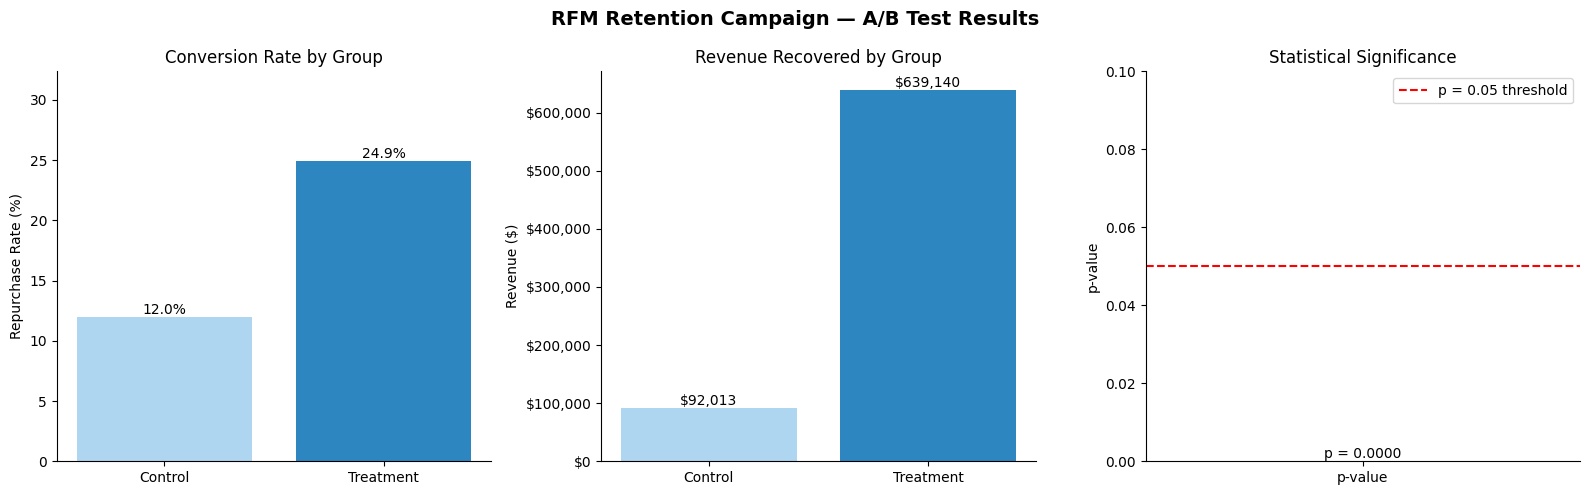

In [14]:
import matplotlib.pyplot as plt

groups = ['Control', 'Treatment']

# Extract values
conv_rates = results.loc[groups, 'conversion_rate_pct']
revenues   = results.loc[groups, 'total_revenue']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Retention Campaign — A/B Test Results',
             fontsize=14, fontweight='bold')

# ---------------- Conversion Rate ----------------
bars = axes[0].bar(groups, conv_rates,
                   color=['#AED6F1', '#2E86C1'])

axes[0].set_title('Conversion Rate by Group')
axes[0].set_ylabel('Repurchase Rate (%)')
axes[0].set_ylim(0, conv_rates.max() * 1.3)

for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():.1f}%',
        ha='center',
        va='bottom'
    )

# ---------------- Revenue ----------------
bars = axes[1].bar(groups, revenues,
                   color=['#AED6F1', '#2E86C1'])

axes[1].set_title('Revenue Recovered by Group')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'${x:,.0f}')
)

for bar in bars:
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'${bar.get_height():,.0f}',
        ha='center',
        va='bottom'
    )

# ---------------- P-value ----------------
color = '#2E86C1' if p_value < 0.05 else '#E74C3C'

axes[2].bar(['p-value'], [p_value], color=color)
axes[2].axhline(0.05, color='red', linestyle='--',
                label='p = 0.05 threshold')

axes[2].set_title('Statistical Significance')
axes[2].set_ylabel('p-value')
axes[2].set_ylim(0, 0.1)
axes[2].legend()

axes[2].text(
    0,
    p_value,
    f'p = {p_value:.4f}',
    ha='center',
    va='bottom'
)

plt.tight_layout()
plt.savefig('ab_test_results.png', dpi=150, bbox_inches='tight')
plt.show()